In [1]:
include("1body_NM.jl")
using LinearAlgebra
using PolyChaos
using QuadGK
using Plots
using ProgressMeter
using Kronecker
using JLD2
using SparseArrays
using .NM_measures_1body

P = set_P()
mu = 0.2
beta = 20.0
gamma = 0.01
T = 30.0
N = Int(T) 

P.spec_fun = "ellipse"
P.T = T
P.N_L = N
P.N_R = N
P.v = 1000
P.Γ_L = gamma
P.Γ_R = gamma
P.β_L = beta
P.β_R = beta
P.μ_L = mu
P.μ_R = mu

calculate_oCP(P; plotting=true)

P = set_P()
mu = 0.1
beta = 20.0
gamma = 0.01
T = 40.0
N = Int(T) 

P.spec_fun = "ellipse"
P.T = T
P.N_L = N
P.N_R = N
P.v = 1000
P.Γ_L = gamma
P.Γ_R = gamma
P.β_L = beta
P.β_R = beta
P.μ_L = mu
P.μ_R = mu

s_times = collect(0.1:0.1:20.0)

PTsignalling = zeros(length(s_times))
PTdivisibility = similar(PTsignalling)
for (i,s) in enumerate(s_times)
    C0 = prepare_corrs(P)
    T_choi = extract_process_tensor(P, C0, s, 2*s)
    PTsignalling[i], PTdivisibility[i] = calculate_PT_oCP(T_choi)
end

p = plot(s_times, PTsignalling, xlabel="\$t = 2s\$",ylabel="Signalling from \$ s \\rightarrow t\$", label="Signalling",
        legend=:topleft, lw=2, dpi=400)
plot!(twinx(p), s_times, PTdivisibility, ylabel="\$||L_{t:0} - L_{t:s:0}||\$", label="Divisibility",legend=:topright, lw=2, c=:red)

display(p)
    
        



Calculating PT Measures... 100%|█████████████████████████| Time: 0:00:42


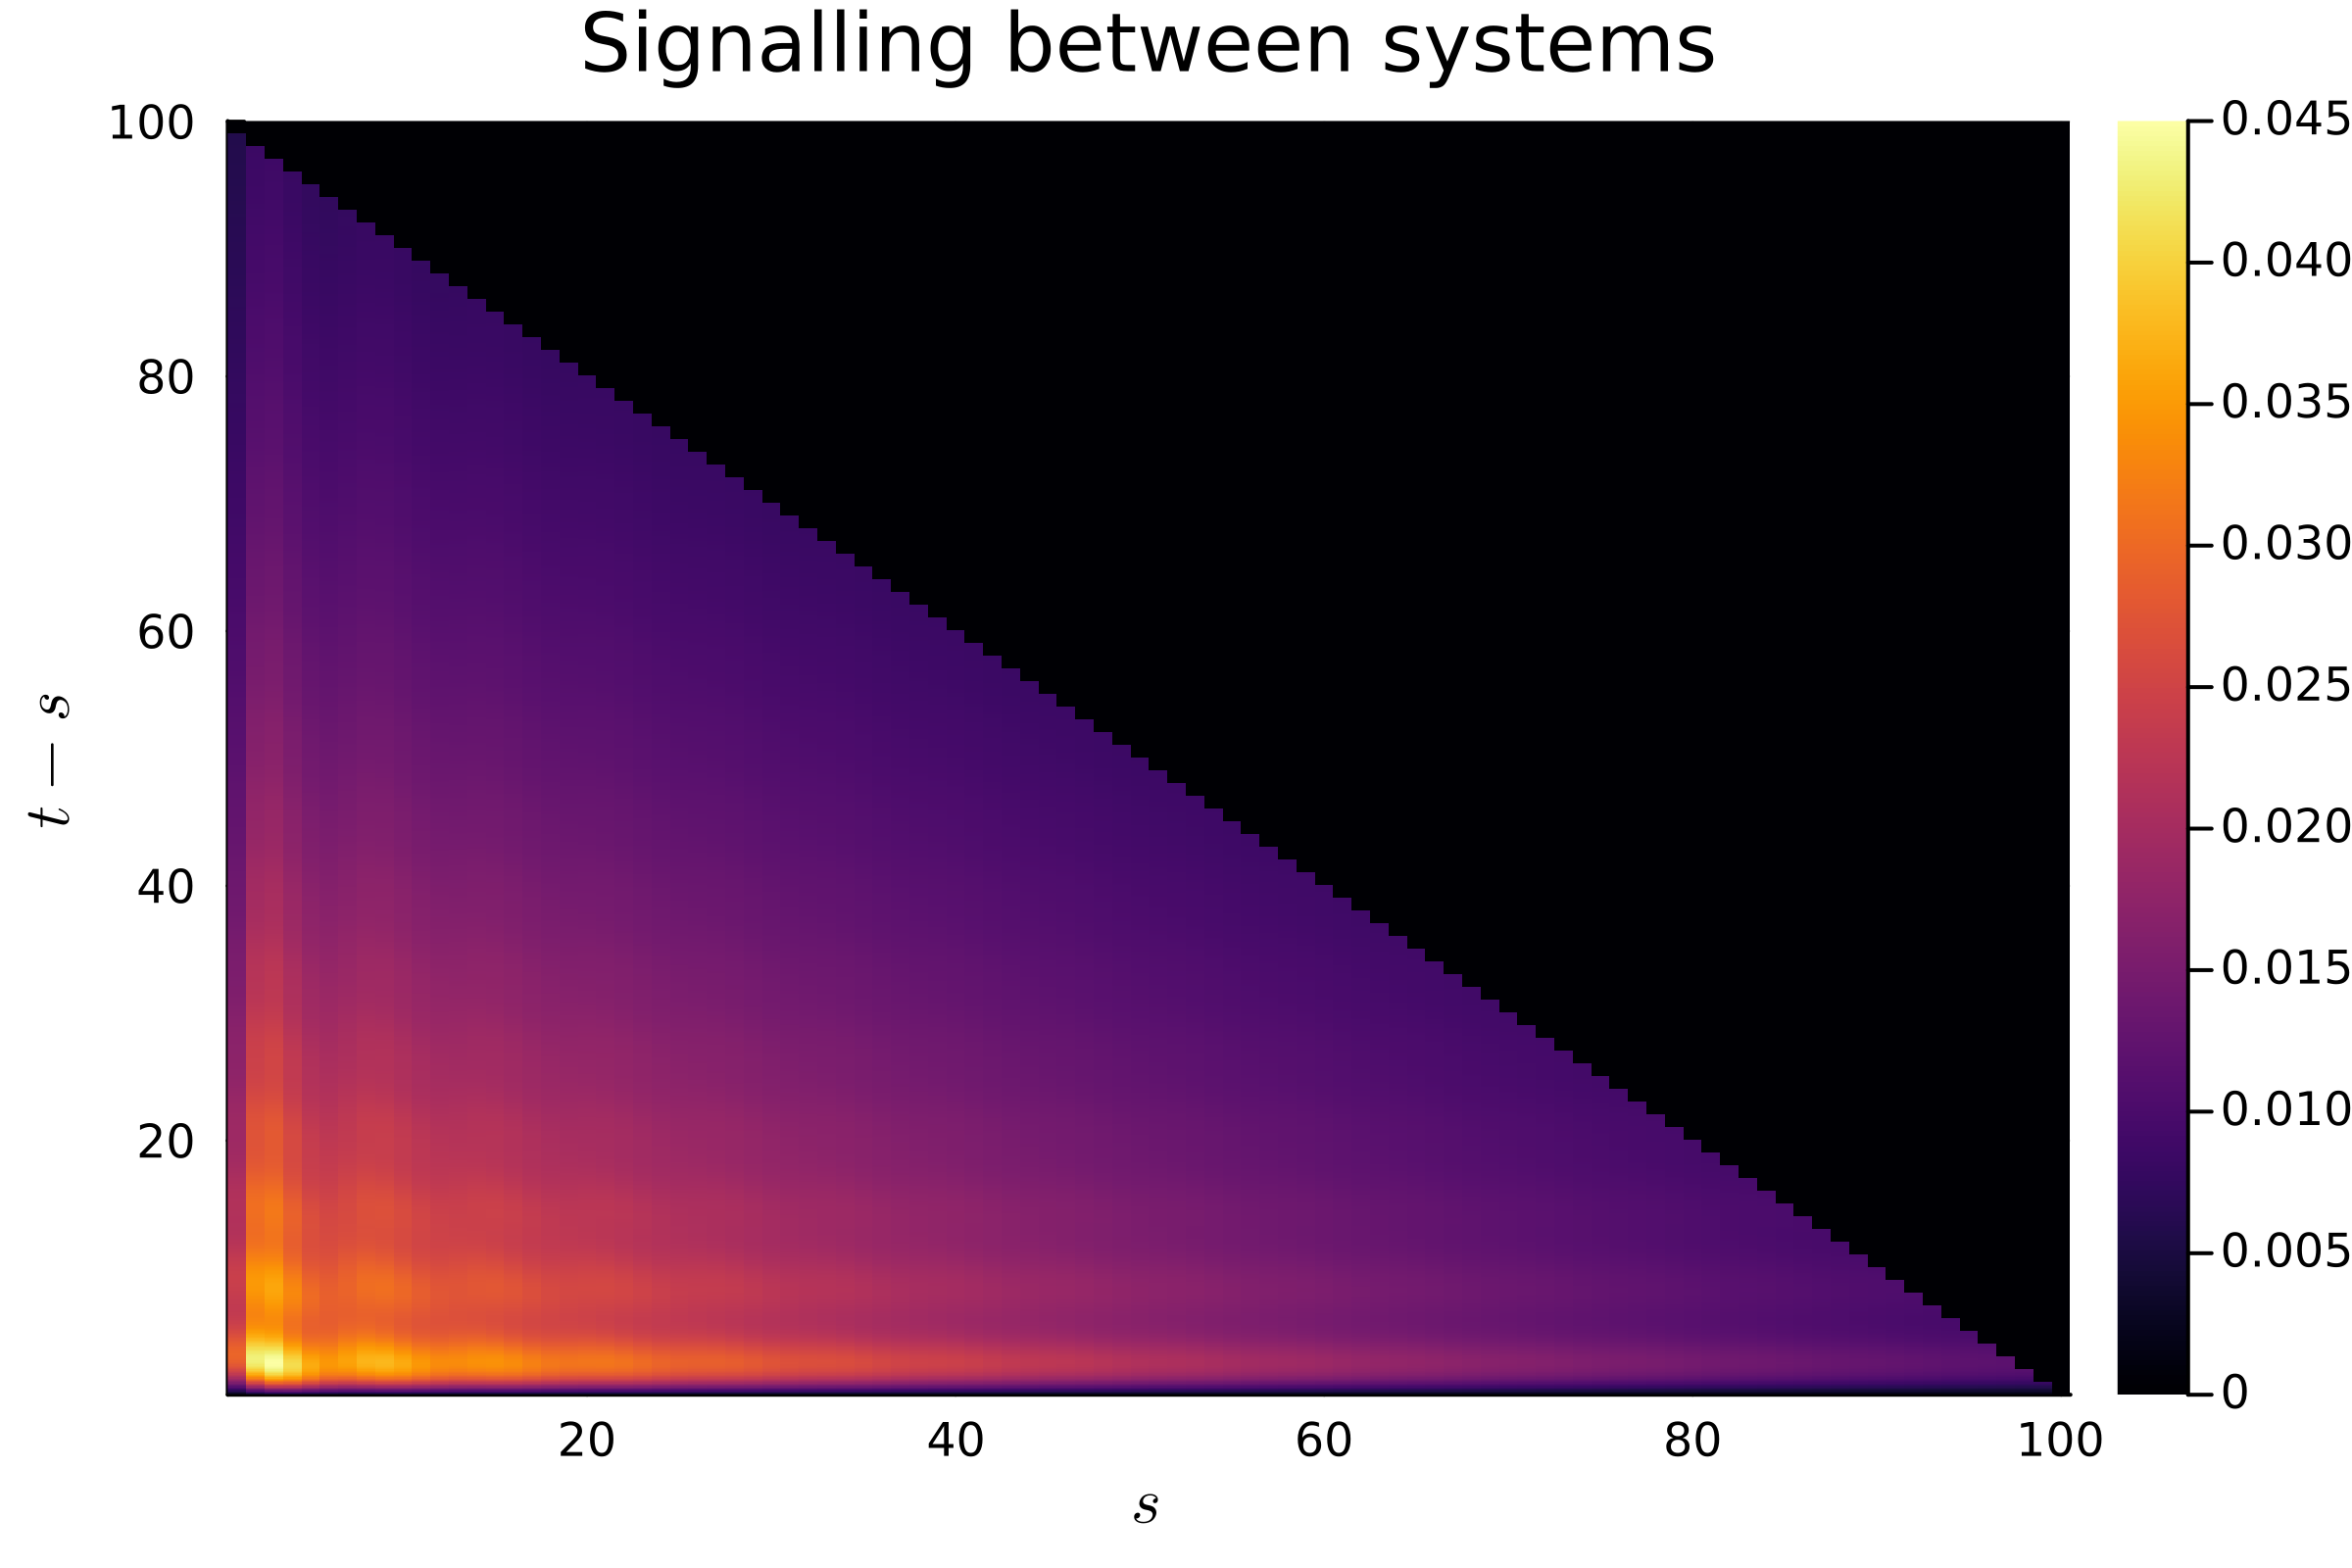

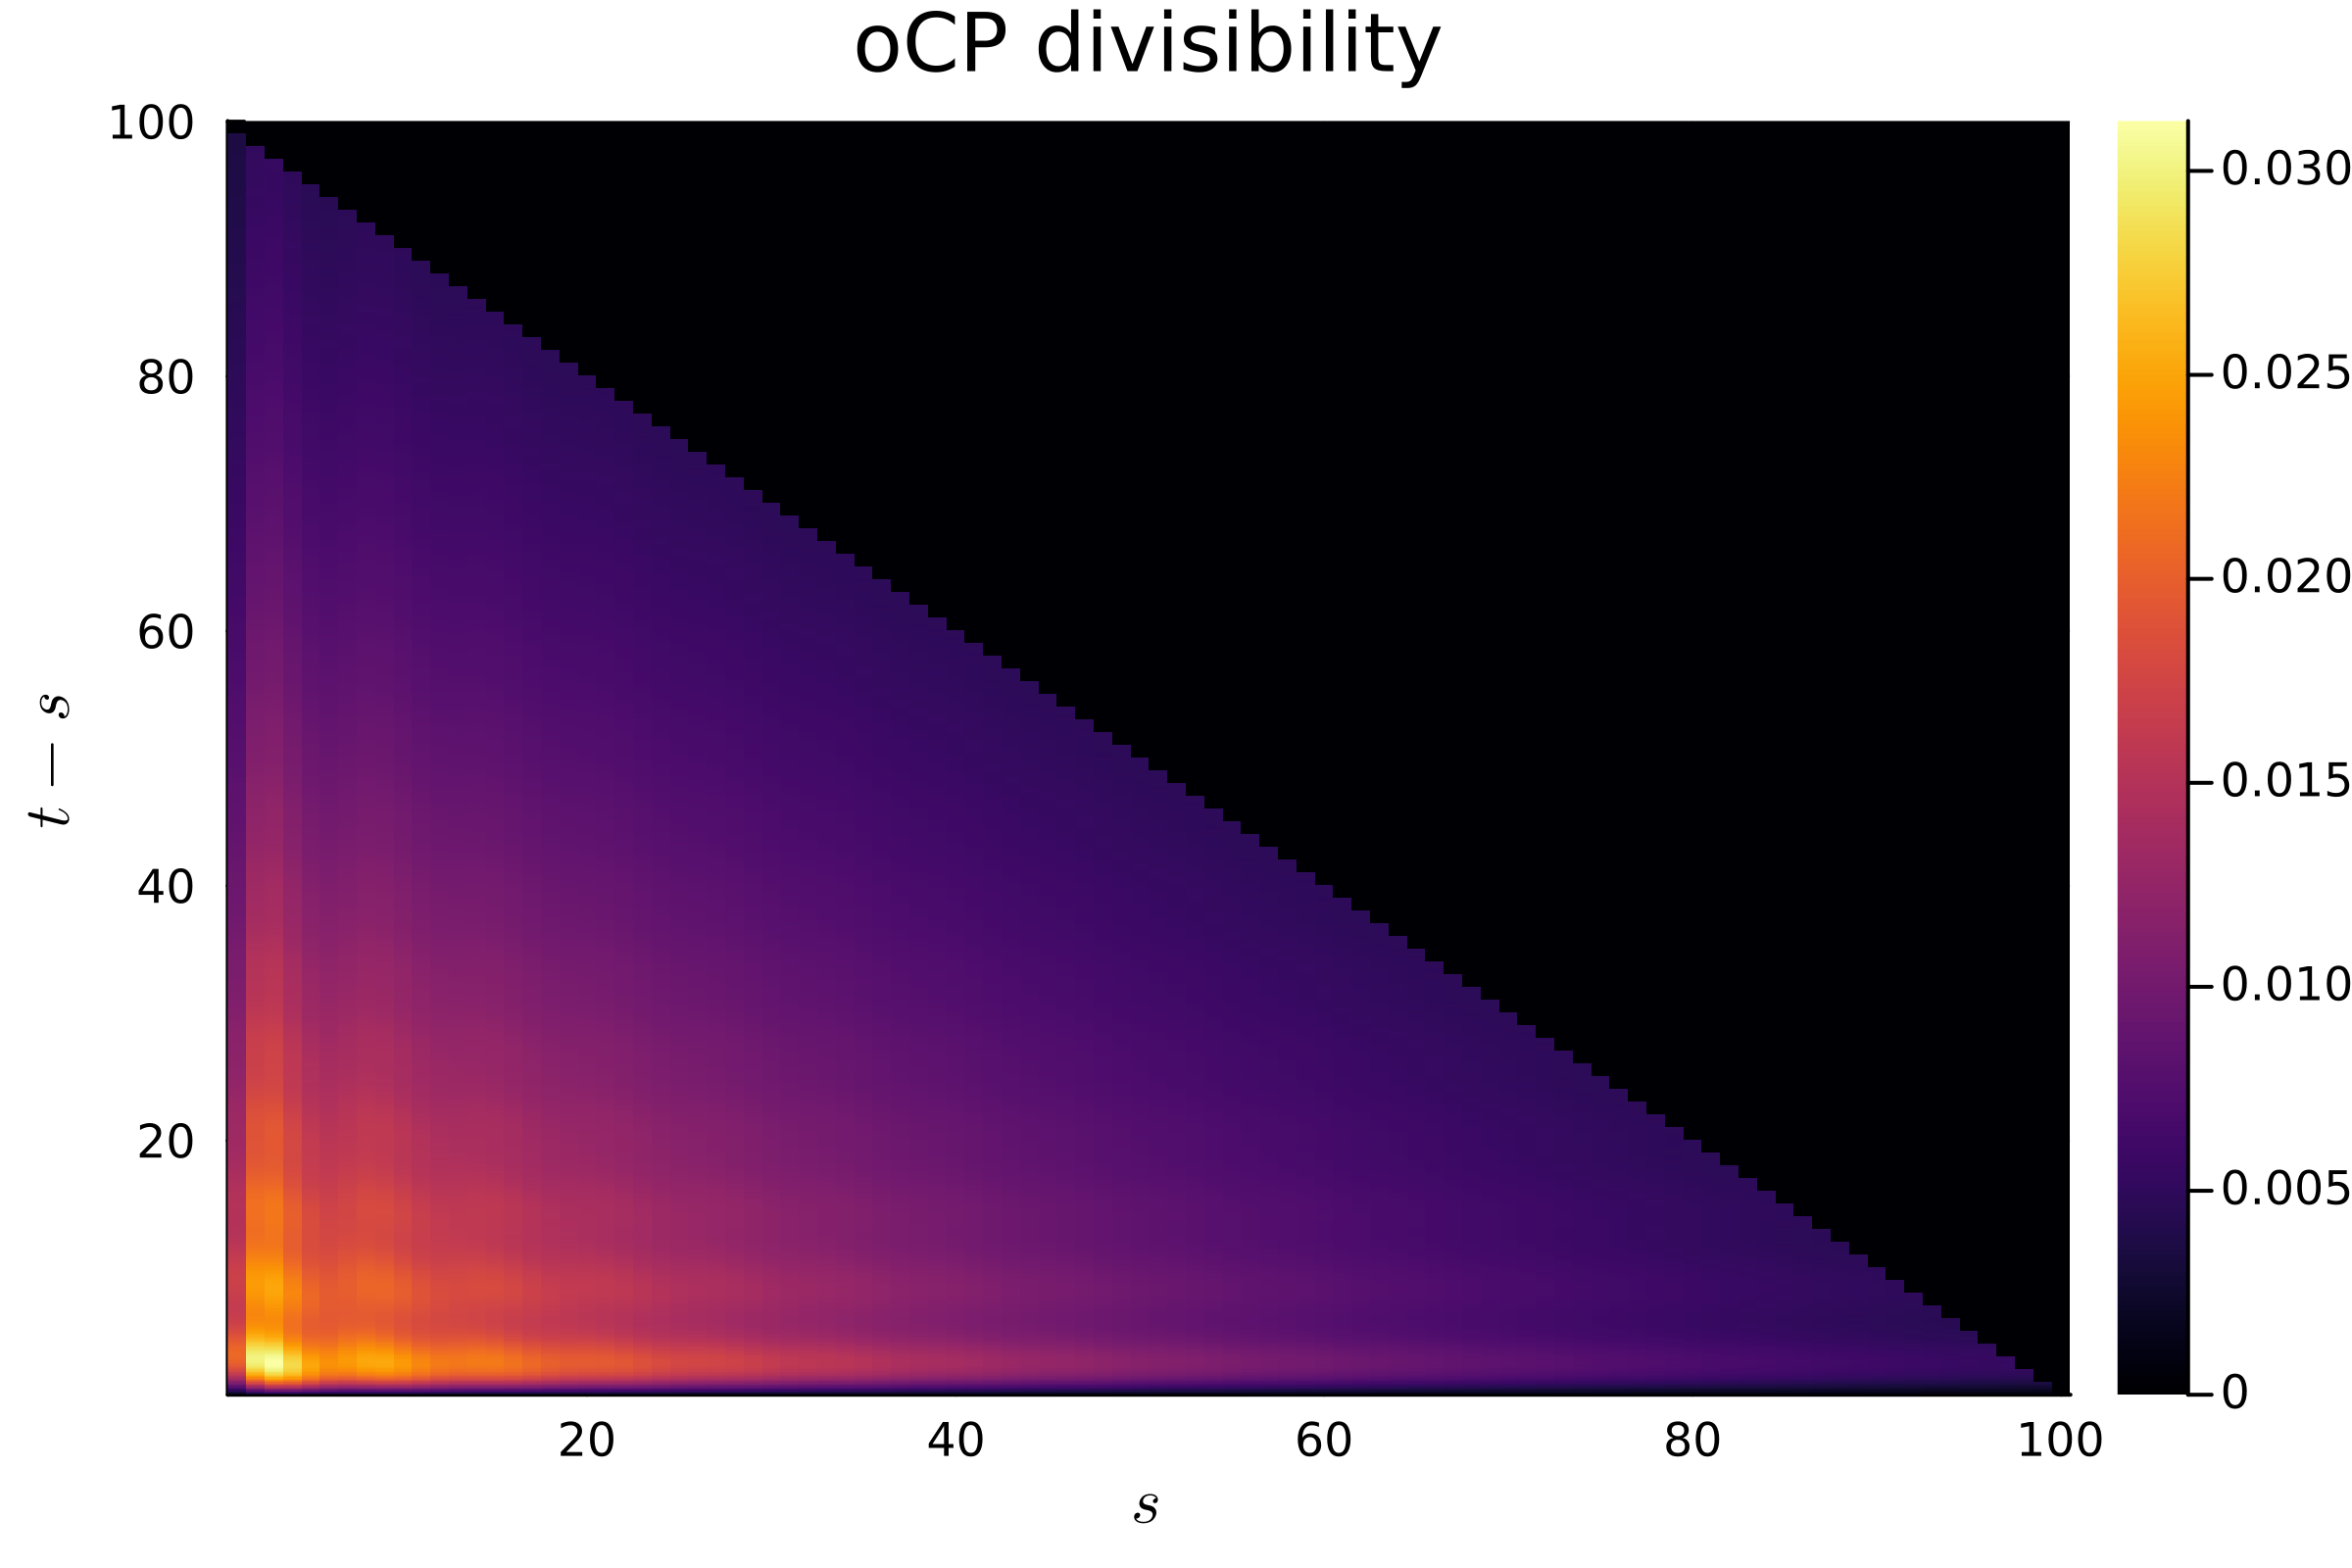

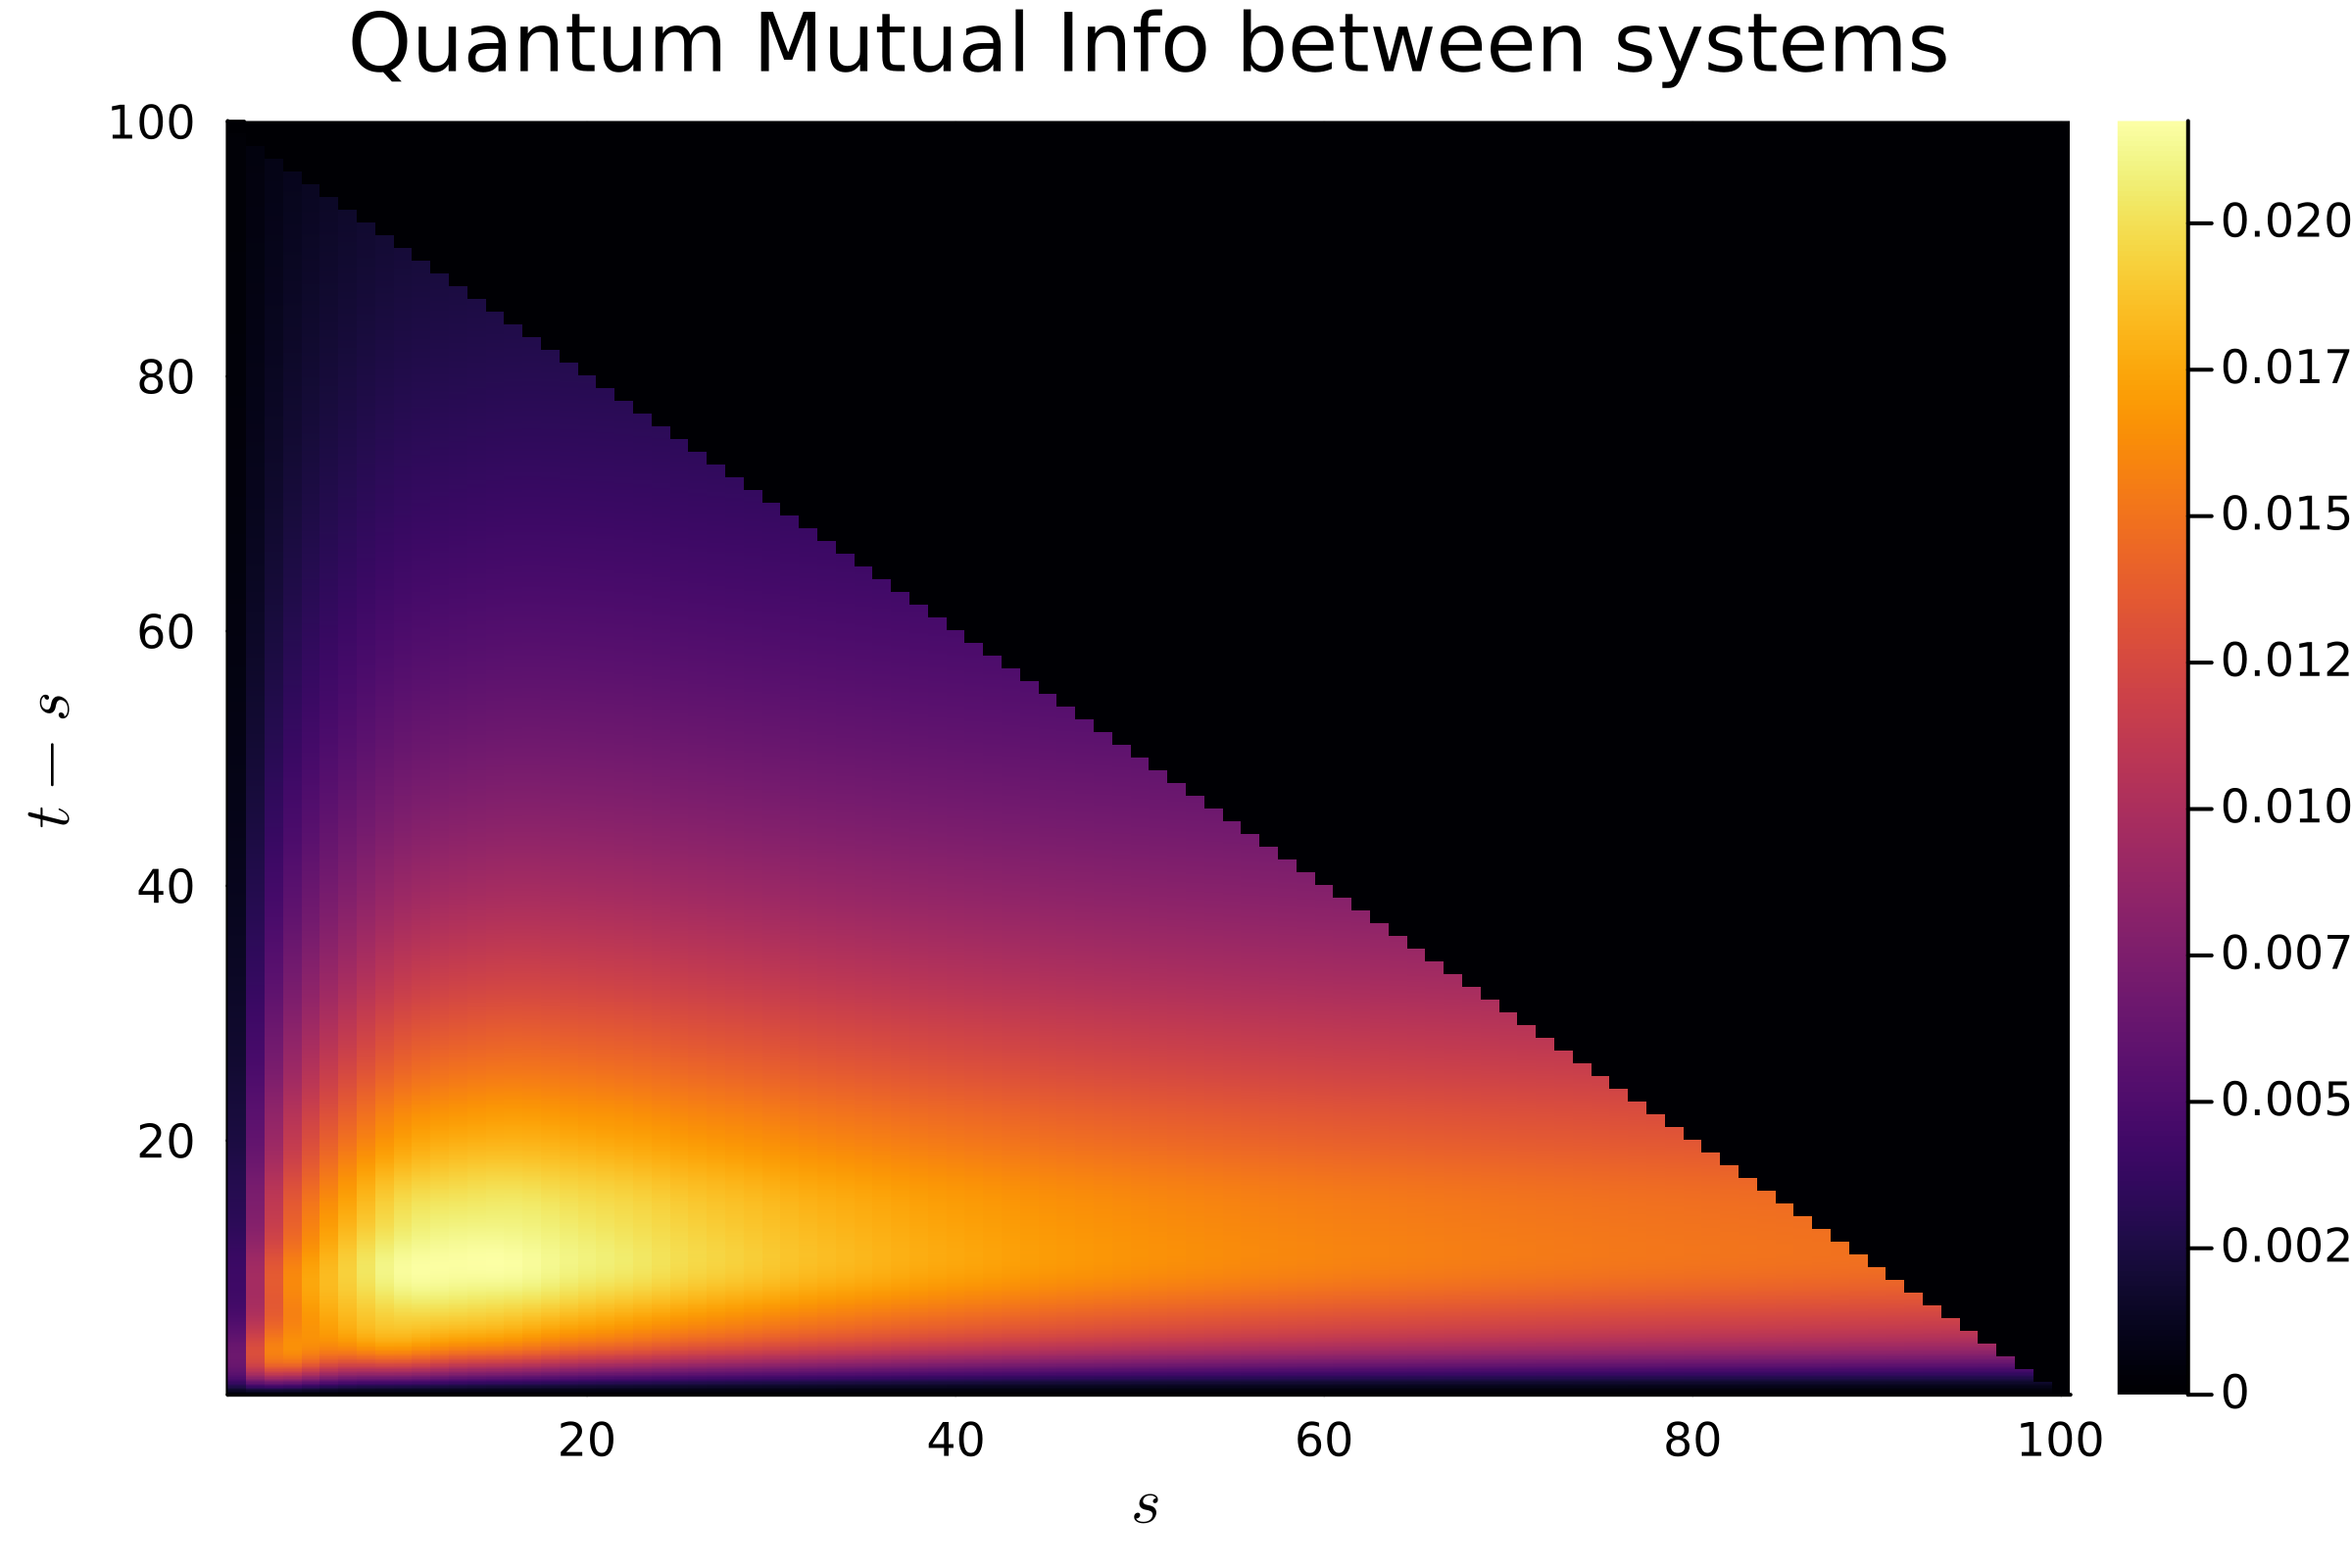

In [ ]:
P = set_P()

mu = 0.0

beta = 20.0

gamma = 0.01

T = 50.0

 

P.spec_fun = "ellipse"

P.v = 1000

P.Γ_L = gamma

P.Γ_R = gamma

P.β_L = beta

P.β_R = beta

P.μ_L = mu

P.μ_R = mu


signalling, divisibility, QMI_s, QMI_0, times, s_times = calculate_PT_measures(P, s_step=1.0)


p = heatmap(s_times, times, signalling, xlabel="\$s\$", ylabel="\$t-s\$", title="Signalling between systems",

        dpi=400)

display(p)

p = heatmap(s_times, times, divisibility, xlabel="\$s\$", ylabel="\$t-s\$", title="oCP divisibility",

        dpi=400)

display(p)

p = heatmap(s_times, times, QMI_s, xlabel="\$s\$", ylabel="\$t-s\$", title="Quantum Mutual Info between systems (s to t)",

        dpi=400)

display(p)

p = heatmap(s_times, times, QMI_0, xlabel="\$s\$", ylabel="\$t-s\$", title="Quantum Mutual Info between systems (0 to t)",

        dpi=400)

display(p)